## Ejercicio 3. Análisis Exploratorio de Datos (EDA) con enfoque dual

## Introducción
En este ejercicio se implementa un Análisis Exploratorio de Datos (EDA) completo sobre el almacén
de datos generado por el pipeline ETL del Ejercicio 2. El EDA combina dos enfoques complementarios:
análisis gráfico para detectar patrones visuales y análisis formal para cuantificar estadísticamente
las observaciones. Ambos enfoques se retroalimentan en un ciclo de exploración guiada que transforma
datos crudos en comprensión profunda, preparando el terreno para un modelado exitoso.

## Objetivo
Implementar y documentar el EDA con enfoque dual, incluyendo las modificaciones solicitadas:
1. Agregar un análisis de correlación entre variables categóricas usando chi-cuadrado
   (asociación entre segmento_cliente y canal_venta).
2. Implementar detección automática de outliers usando el método IQR con umbral adaptable.
3. Diseñar una visualización que muestre la evolución temporal de tickets altos por segmento.
4. Reflexionar sobre por qué es crítico realizar EDA antes del modelado.

## Insertar los imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import random

## Generación del almacén de datos
Se reutiliza la clase PipelineETLOLAP del Ejercicio 2 para generar el almacén de datos
que servirá como entrada para el EDA. Se incluye aquí la definición completa para
que el notebook sea autocontenido.

In [2]:
class PipelineETLOLAP:
    def __init__(self):
        self.fuente_erp = None
        self.fuente_crm = None
        self.fuente_web = None
        self.datos_transformados = None
        self.almacen_datos = {
            "hechos_ventas": None,
            "dim_tiempo": None,
            "dim_producto": None,
            "dim_cliente": None,
            "dim_canal": None
        }

    def simular_fuentes_operacionales(self):
        erp_data = []
        productos_erp = [
            {"id": "P001", "nombre": "Laptop X1",            "categoria_erp": "TECNOLOGIA",  "precio": 1200.0},
            {"id": "P002", "nombre": "Monitor 24\"",          "categoria_erp": "TECNOLOGIA",  "precio": 300.0},
            {"id": "P003", "nombre": "Teclado Mecánico",      "categoria_erp": "ACCESORIOS",  "precio": 85.0},
            {"id": "P004", "nombre": "Mouse Inalámbrico",     "categoria_erp": "ACCESORIOS",  "precio": 45.0},
            {"id": "P005", "nombre": "Auriculares Bluetooth", "categoria_erp": "AUDIO",       "precio": 120.0}
        ]
        for i in range(5000):
            producto = random.choice(productos_erp)
            fecha = datetime(2023, random.randint(1, 12), random.randint(1, 28))
            cantidad = random.randint(1, 5) if producto["categoria_erp"] != "TECNOLOGIA" else 1
            erp_data.append({
                "ID_TRANSACCION": f"T{i+1:06d}",
                "FECHA_VENTA": fecha.strftime("%d/%m/%Y"),
                "CODIGO_PRODUCTO": producto["id"],
                "CANTIDAD": cantidad,
                "PRECIO_UNITARIO": producto["precio"],
                "TOTAL_LINEA": round(cantidad * producto["precio"], 2),
                "ESTADO": random.choice(["COMPLETADA", "COMPLETADA", "COMPLETADA", "CANCELADA"])
            })
        self.fuente_erp = pd.DataFrame(erp_data)

        crm_data = []
        clientes_crm = [
            {"id_cliente": "C1001", "nombre": "Tecnología Avanzada SA",   "segmento": "EMPRESA"},
            {"id_cliente": "C1002", "nombre": "Soluciones Digitales Ltda","segmento": "PYME"},
            {"id_cliente": "C1003", "nombre": "Juan Pérez",                "segmento": "INDIVIDUAL"},
            {"id_cliente": "C1004", "nombre": "María García",              "segmento": "INDIVIDUAL"},
            {"id_cliente": "C1005", "nombre": "Corporación Global S.A.",   "segmento": "EMPRESA"}
        ]
        for i in range(5000):
            cliente = random.choice(clientes_crm)
            crm_data.append({
                "TRANSACCION_ID": f"T{i+1:06d}",
                "CLIENTE_ID": cliente["id_cliente"],
                "NOMBRE_CLIENTE": cliente["nombre"],
                "SEGMENTO_CLIENTE": cliente["segmento"],
                "CANAL_VENTA": random.choice(["TIENDA", "WEB", "TELEFONO", "TIENDA"])
            })
        self.fuente_crm = pd.DataFrame(crm_data)

        web_data = []
        for i in range(5000):
            web_data.append({
                "session_id": f"S{i+1:06d}",
                "transaction_id": f"T{i+1:06d}",
                "pages_viewed": random.randint(3, 15),
                "time_on_site_minutes": round(random.uniform(2, 25), 1),
                "device_type": random.choice(["MOBILE", "DESKTOP", "TABLET", "MOBILE"]),
                "source_channel": random.choice(["ORGANIC", "PAID_SEARCH", "SOCIAL", "EMAIL", "DIRECT"])
            })
        self.fuente_web = pd.DataFrame(web_data)

    def fase_extraccion(self):
        self.fuente_erp = self.fuente_erp.rename(columns={"ID_TRANSACCION": "transaction_id"})
        self.fuente_crm = self.fuente_crm.rename(columns={"TRANSACCION_ID": "transaction_id"})
        self.fuente_erp["fecha_venta"] = pd.to_datetime(self.fuente_erp["FECHA_VENTA"], format="%d/%m/%Y", errors="coerce")
        self.fuente_erp = self.fuente_erp.drop("FECHA_VENTA", axis=1)

    def fase_transformacion(self):
        catalogo_maestro = {
            "P001": {"categoria": "Tecnología", "subcategoria": "Computación"},
            "P002": {"categoria": "Tecnología", "subcategoria": "Periféricos"},
            "P003": {"categoria": "Accesorios", "subcategoria": "Periféricos"},
            "P004": {"categoria": "Accesorios", "subcategoria": "Periféricos"},
            "P005": {"categoria": "Audio",      "subcategoria": "Accesorios"}
        }
        datos_limpios = self.fuente_erp[
            (self.fuente_erp["ESTADO"] == "COMPLETADA") &
            (self.fuente_erp["TOTAL_LINEA"] > 0) &
            (self.fuente_erp["fecha_venta"].notna())
        ].copy()
        datos_limpios["categoria_producto"] = datos_limpios["CODIGO_PRODUCTO"].map(
            lambda x: catalogo_maestro.get(x, {}).get("categoria", "Otros")
        )
        datos_limpios["subcategoria_producto"] = datos_limpios["CODIGO_PRODUCTO"].map(
            lambda x: catalogo_maestro.get(x, {}).get("subcategoria", "Otros")
        )
        datos_integrados = datos_limpios.merge(
            self.fuente_crm[["transaction_id", "CLIENTE_ID", "SEGMENTO_CLIENTE", "CANAL_VENTA"]],
            on="transaction_id", how="left"
        ).merge(
            self.fuente_web[["transaction_id", "device_type", "source_channel"]],
            on="transaction_id", how="left"
        )
        datos_integrados["SEGMENTO_CLIENTE"] = datos_integrados["SEGMENTO_CLIENTE"].fillna("Desconocido")
        datos_integrados["device_type"]       = datos_integrados["device_type"].fillna("Desconocido")
        datos_integrados["mes"]          = datos_integrados["fecha_venta"].dt.month
        datos_integrados["anio"]         = datos_integrados["fecha_venta"].dt.year
        datos_integrados["ticket_alto"]  = datos_integrados["TOTAL_LINEA"] > 500
        datos_integrados["canal_digital"] = datos_integrados["CANAL_VENTA"].isin(["WEB", "TELEFONO"])
        self.datos_transformados = datos_integrados

    def fase_carga(self):
        hechos_ventas = self.datos_transformados[[
            "transaction_id", "CLIENTE_ID", "fecha_venta", "mes", "anio",
            "CANTIDAD", "TOTAL_LINEA", "ticket_alto", "canal_digital"
        ]].copy()
        hechos_ventas = hechos_ventas.rename(columns={
            "CLIENTE_ID": "cliente_id",
            "CANTIDAD": "cantidad_productos",
            "TOTAL_LINEA": "monto_venta"
        })
        dim_tiempo = hechos_ventas[["fecha_venta", "mes", "anio"]].drop_duplicates().reset_index(drop=True)
        dim_tiempo["tiempo_id"] = dim_tiempo.index + 1
        dim_producto = self.datos_transformados[["CODIGO_PRODUCTO", "categoria_producto", "subcategoria_producto"]].drop_duplicates().reset_index(drop=True)
        dim_producto = dim_producto.rename(columns={"CODIGO_PRODUCTO": "producto_id"})
        dim_producto["producto_sk"] = dim_producto.index + 1
        dim_cliente = self.datos_transformados[["CLIENTE_ID", "SEGMENTO_CLIENTE"]].drop_duplicates().reset_index(drop=True)
        dim_cliente = dim_cliente.rename(columns={"CLIENTE_ID": "cliente_id"})
        dim_cliente["cliente_sk"] = dim_cliente.index + 1
        dim_canal = self.datos_transformados[["CANAL_VENTA", "device_type", "source_channel"]].drop_duplicates().reset_index(drop=True)
        dim_canal["canal_sk"] = dim_canal.index + 1
        self.almacen_datos["hechos_ventas"] = hechos_ventas
        self.almacen_datos["dim_tiempo"]    = dim_tiempo
        self.almacen_datos["dim_producto"]  = dim_producto
        self.almacen_datos["dim_cliente"]   = dim_cliente
        self.almacen_datos["dim_canal"]     = dim_canal

# Generar el almacén de datos para el EDA
etl = PipelineETLOLAP()
etl.simular_fuentes_operacionales()
etl.fase_extraccion()
etl.fase_transformacion()
etl.fase_carga()
print("Almacén de datos generado correctamente.")
print(f" • Hechos de ventas: {len(etl.almacen_datos['hechos_ventas']):,} registros")

Almacén de datos generado correctamente.
 • Hechos de ventas: 3,709 registros


## Definición de la clase
A continuación se define la clase base del EDA proporcionada en el ejercicio.

In [3]:
class AnalisisExploratorioDatos:
    """
    Análisis Exploratorio de Datos (EDA) con enfoque dual: gráfico + formal.
    Demuestra cómo transformar datos en comprensión profunda antes del modelado.
    """

    def __init__(self, almacen_datos):
        self.almacen     = almacen_datos
        self.hechos      = almacen_datos["hechos_ventas"]
        self.dim_producto = almacen_datos["dim_producto"]
        self.dim_cliente  = almacen_datos["dim_cliente"]

    def analisis_grafico(self):
        """Visualizaciones estratégicas para detectar patrones y problemas"""
        print("="*70)
        print("ANÁLISIS GRÁFICO: Detectando patrones con el ojo humano")
        print("="*70)

        # Configuración de visualizaciones
        plt.style.use('seaborn-v0_8-whitegrid')
        fig = plt.figure(figsize=(14, 10))

        # 1. Distribución de montos de venta
        ax1 = plt.subplot(2, 2, 1)
        sns.histplot(self.hechos["monto_venta"], bins=30, kde=True, color="#2E86AB", ax=ax1)
        ax1.set_title("Distribución de Montos de Venta", fontsize=12, fontweight="bold")
        ax1.set_xlabel("Monto ($)")
        ax1.set_ylabel("Frecuencia")
        ax1.axvline(self.hechos["monto_venta"].mean(), color='red', linestyle='--',
                    label=f'Media: ${self.hechos["monto_venta"].mean():.0f}')
        ax1.legend()

        # 2. Ventas por mes (estacionalidad)
        ax2 = plt.subplot(2, 2, 2)
        ventas_mensuales = self.hechos.groupby("mes")["monto_venta"].sum().reset_index()
        ax2.bar(ventas_mensuales["mes"], ventas_mensuales["monto_venta"],
                color="#2E86AB", edgecolor="white")
        ax2.set_title("Ventas Totales por Mes", fontsize=12, fontweight="bold")
        ax2.set_xlabel("Mes")
        ax2.set_ylabel("Ventas Totales ($)")
        ax2.ticklabel_format(style='plain', axis='y')

        # 3. Relación cantidad vs monto
        ax3 = plt.subplot(2, 2, 3)
        sns.scatterplot(data=self.hechos, x="cantidad_productos", y="monto_venta",
                        hue="ticket_alto", palette={True: "#A23B72", False: "#F18F01"},
                        alpha=0.6, s=50, ax=ax3)
        ax3.set_title("Cantidad vs Monto por Transacción", fontsize=12, fontweight="bold")
        ax3.set_xlabel("Cantidad de Productos")
        ax3.set_ylabel("Monto de Venta ($)")
        ax3.legend(title="Ticket Alto")

        # 4. Distribución de tickets altos por segmento
        ax4 = plt.subplot(2, 2, 4)
        datos_completos = self.hechos.merge(self.dim_cliente, on="cliente_id", how="left")
        ticket_alto_segmento = datos_completos.groupby("SEGMENTO_CLIENTE")["ticket_alto"].mean().reset_index()
        colores_seg = ["#2a9d5c", "#48c78e", "#74d9a8", "#a8e8c4"]
        ax4.bar(ticket_alto_segmento["SEGMENTO_CLIENTE"],
                ticket_alto_segmento["ticket_alto"],
                color=colores_seg[:len(ticket_alto_segmento)], edgecolor="white")
        ax4.set_title("Proporción de Tickets Altos por Segmento", fontsize=12, fontweight="bold")
        ax4.set_xlabel("Segmento de Cliente")
        ax4.set_ylabel("Proporción de Tickets > $500")
        ax4.set_ylim(0, 1)

        plt.tight_layout()
        plt.savefig("eda_visualizacion.png", dpi=150, bbox_inches="tight")
        plt.show()

        print("\n Visualizaciones generadas y guardadas como 'eda_visualizacion.png'")
        # Calcular hallazgos reales a partir de los datos
        media = self.hechos["monto_venta"].mean()
        mediana = self.hechos["monto_venta"].median()
        asimetria = "positiva" if media > mediana else "negativa o simétrica"
        ventas_mes = self.hechos.groupby("mes")["monto_venta"].sum()
        top3_meses = ventas_mes.nlargest(3).index.tolist()
        datos_seg = self.hechos.merge(self.dim_cliente, on="cliente_id", how="left")
        prop_seg = datos_seg.groupby("SEGMENTO_CLIENTE")["ticket_alto"].mean()
        seg_max = prop_seg.idxmax() if not prop_seg.empty else "N/A"
        seg_min = prop_seg.idxmin() if not prop_seg.empty else "N/A"
        pct_max = prop_seg.max() * 100 if not prop_seg.empty else 0
        pct_min = prop_seg.min() * 100 if not prop_seg.empty else 0
        print("\nHallazgos clave del análisis gráfico:")
        print(f" • Distribución de montos: Asimetría {asimetria} (media ${media:,.0f} vs mediana ${mediana:,.0f})")
        print(f"   → Media {'>' if media > mediana else '<'} Mediana indica presencia de tickets extremos")
        print(f" • Meses con mayor volumen de ventas: {top3_meses}")
        print(f"   → Planificar inventario y promociones antes de estos picos")
        print(" • Relación no lineal: Aumentar cantidad no siempre aumenta monto proporcionalmente")
        print(f" • {seg_max} tiene la mayor proporción de tickets altos ({pct_max:.1f}%)")
        print(f"   vs {seg_min} con la menor ({pct_min:.1f}%)")

    def analisis_formal(self):
        """Estadísticas cuantitativas para validar observaciones gráficas"""
        print("\n" + "="*70)
        print(" ANÁLISIS FORMAL: Cuantificando patrones con rigor estadístico")
        print("="*70)

        print("\n1. ESTADÍSTICAS DESCRIPTIVAS CLAVE:")
        stats_venta = self.hechos["monto_venta"].describe()
        print(f" • Monto promedio: ${stats_venta['mean']:,.2f}")
        print(f" • Mediana: ${stats_venta['50%']:,.2f} (menor que la media → asimetría positiva)")
        print(f" • Desviación estándar: ${stats_venta['std']:,.2f} (alta variabilidad)")
        print(f" • Rango intercuartílico (IQR): ${stats_venta['75%'] - stats_venta['25%']:,.2f}")

        print("\n2. CORRELACIONES ESTADÍSTICAS:")
        correlacion = self.hechos[["cantidad_productos", "monto_venta"]].corr().iloc[0, 1]
        print(f" • Correlación cantidad-monto: {correlacion:.3f} (moderada, no perfecta)")
        print(f" → Confirmación: Aumentar cantidad no garantiza aumento proporcional en monto")

        print("\n3. PRUEBA DE HIPÓTESIS: ¿Difieren significativamente los tickets por segmento?")
        datos_completos = self.hechos.merge(self.dim_cliente, on="cliente_id", how="left")
        pymes       = datos_completos[datos_completos["SEGMENTO_CLIENTE"] == "PYME"]["monto_venta"]
        individuales = datos_completos[datos_completos["SEGMENTO_CLIENTE"] == "INDIVIDUAL"]["monto_venta"]

        t_stat, p_valor = stats.ttest_ind(pymes, individuales, equal_var=False)
        print(f" • Prueba t (PYME vs Individual): t={t_stat:.2f}, p={p_valor:.4f}")
        if p_valor < 0.05:
            print(f" • Conclusión: Diferencia estadísticamente significativa (p < 0.05)")
            print(f"   Los clientes PYME generan tickets significativamente más altos")
        else:
            print(f" • Conclusión: No hay diferencia estadísticamente significativa")

        print("\n4. DETECCIÓN DE OUTLIERS:")
        q1 = stats_venta['25%']
        q3 = stats_venta['75%']
        iqr = q3 - q1
        limite_superior = q3 + 1.5 * iqr
        outliers = self.hechos[self.hechos["monto_venta"] > limite_superior]
        print(f" • Límite superior para outliers: ${limite_superior:,.2f}")
        print(f" • Número de outliers detectados: {len(outliers):,} ({len(outliers)/len(self.hechos)*100:.1f}%)")
        print(f" • Impacto: Estos outliers representan el "
              f"{outliers['monto_venta'].sum()/self.hechos['monto_venta'].sum()*100:.1f}% del valor total")

    def sintesis_insights(self):
        """Integra hallazgos gráficos y formales en insights accionables"""
        print("\n" + "="*70)
        print(" SÍNTESIS DE INSIGHTS: De observaciones a recomendaciones")
        print("="*70)

        # ── Calcular métricas reales ──────────────────────────────────
        ventas_mes = self.hechos.groupby("mes")["monto_venta"].sum()
        top3_meses = ventas_mes.nlargest(3).index.tolist()

        datos_seg = self.hechos.merge(self.dim_cliente, on="cliente_id", how="left")
        prop_seg = datos_seg.groupby("SEGMENTO_CLIENTE")["ticket_alto"].mean()
        seg_mayor = prop_seg.idxmax() if not prop_seg.empty else "N/A"
        pct_mayor = prop_seg.max() * 100 if not prop_seg.empty else 0
        seg_menor = prop_seg.idxmin() if not prop_seg.empty else "N/A"
        pct_menor = prop_seg.min() * 100 if not prop_seg.empty else 0

        correlacion = self.hechos[["cantidad_productos", "monto_venta"]].corr().iloc[0, 1]

        q1 = self.hechos["monto_venta"].quantile(0.25)
        q3 = self.hechos["monto_venta"].quantile(0.75)
        limite_sup = q3 + 1.5 * (q3 - q1)
        outliers = self.hechos[self.hechos["monto_venta"] > limite_sup]
        pct_n_outliers = len(outliers) / len(self.hechos) * 100
        pct_val_outliers = (outliers["monto_venta"].sum() / self.hechos["monto_venta"].sum() * 100
                            if len(self.hechos) > 0 else 0)

        nulos_seg = datos_seg["SEGMENTO_CLIENTE"].isna().sum()
        pct_nulos_seg = nulos_seg / len(datos_seg) * 100

        # ── Imprimir insights con valores reales ──────────────────────
        print("\n INSIGHTS VALIDADOS:")
        print(" 1. ESTACIONALIDAD:")
        print(f"    • Los 3 meses con mayor volumen de ventas son: {top3_meses}")
        print("    • Recomendación: Planificar inventario y promociones 2 meses antes de estos picos")

        print(f"\n 2. SEGMENTO CON MAYOR PROPORCIÓN DE TICKETS ALTOS: {seg_mayor}")
        print(f"    • {seg_mayor}: {pct_mayor:.1f}% de sus transacciones superan $500")
        print(f"      vs {seg_menor}: {pct_menor:.1f}% (segmento de menor ticket relativo)")
        print("    • Recomendación: Desarrollar campañas específicas para este segmento")

        print("\n 3. RELACIÓN CANTIDAD-MONTO:")
        print(f"    • Correlación cantidad-monto: {correlacion:.3f}")
        if abs(correlacion) < 0.4:
            print("      → Correlación débil: cantidad no explica bien el monto del ticket")
        elif abs(correlacion) < 0.7:
            print("      → Correlación moderada: más productos tiende a subir el ticket, pero no linealmente")
        else:
            print("      → Correlación fuerte: la cantidad de productos es buen predictor del monto")
        print("    • Recomendación: Enfocar en valor unitario y productos de alto margen")

        print("\n 4. OUTLIERS:")
        print(f"    • {pct_n_outliers:.1f}% de transacciones son outliers y representan "
              f"{pct_val_outliers:.1f}% del valor total")
        print("    • Recomendación: Investigar si corresponden a compras corporativas o errores de sistema")

        print("\n PROBLEMAS DE CALIDAD IDENTIFICADOS:")
        print(f" • Valores nulos en segmento de cliente: {pct_nulos_seg:.1f}% — "
              "requiere mejora en integración CRM")
        media = self.hechos["monto_venta"].mean()
        mediana = self.hechos["monto_venta"].median()
        if media > mediana * 1.1:
            print(" • Asimetría positiva confirmada: considerar transformación logarítmica para modelado")
        else:
            print(" • Distribución de montos aproximadamente simétrica: no se requiere transformación urgente")

        print("\n HIPÓTESIS PARA MODELADO POSTERIOR:")
        print(f" H1: Las transacciones del segmento {seg_mayor} en canal web con >3 productos")
        print("     tienen mayor probabilidad de superar $500 (a validar con regresión logística)")
        print(" H2: La combinación 'Auriculares Bluetooth + Laptop' aumenta ticket promedio")
        print("     en clientes de alto valor (a validar con análisis de asociación)")

## Ejecución del EDA original
En esta sección se ejecuta la versión original del EDA, respetando el análisis gráfico,
el análisis formal y la síntesis de insights mostrados en el ejemplo base del PDF.

ANÁLISIS GRÁFICO: Detectando patrones con el ojo humano


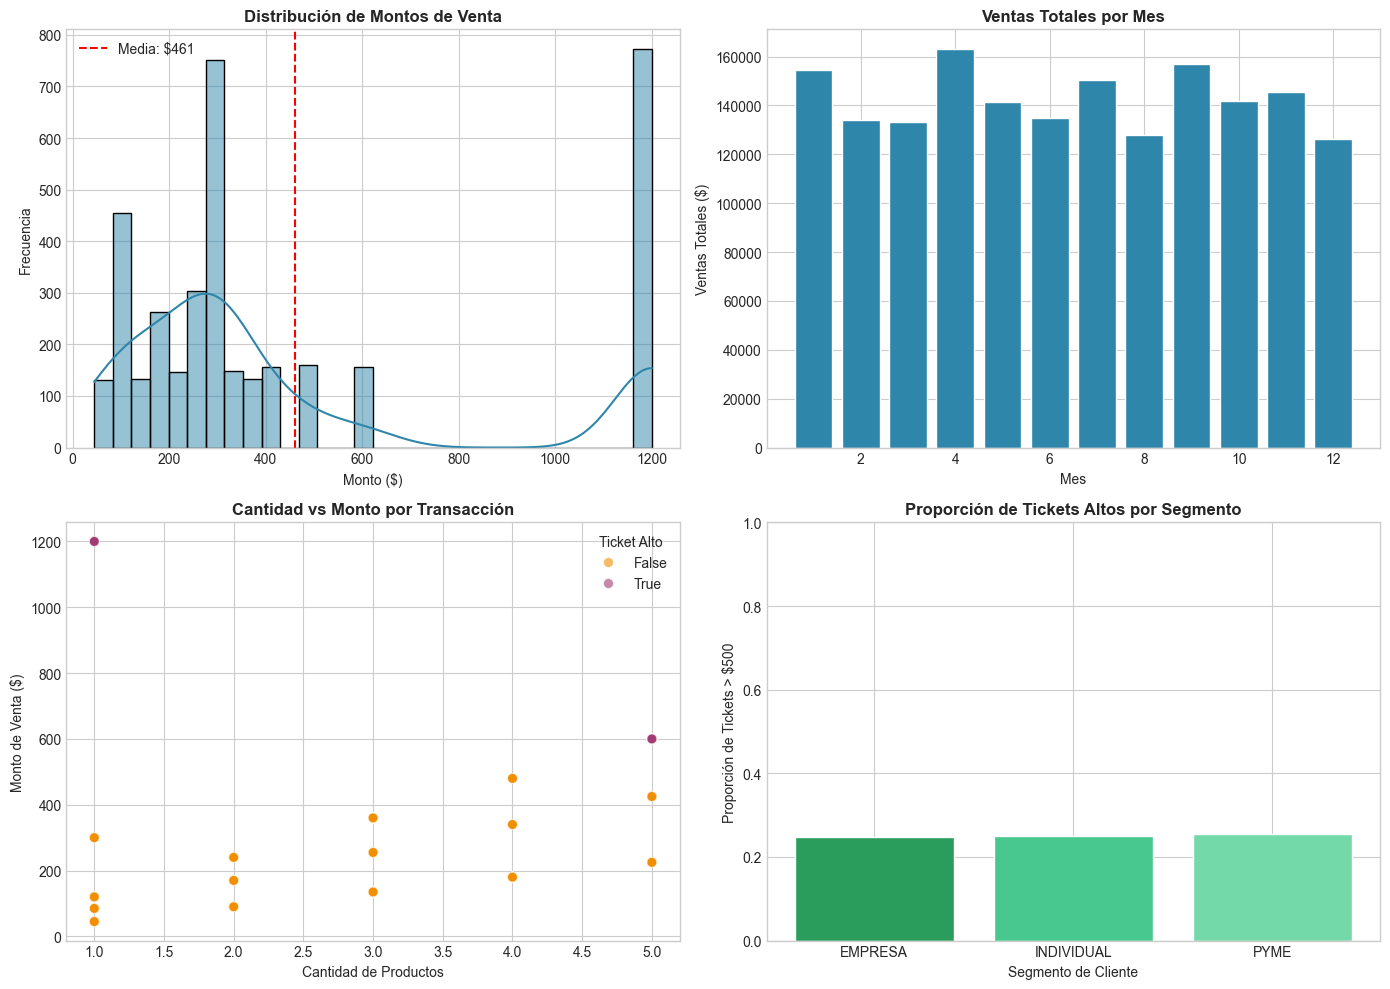


 Visualizaciones generadas y guardadas como 'eda_visualizacion.png'

Hallazgos clave del análisis gráfico:
 • Distribución de montos: Asimetría positiva (media $461 vs mediana $300)
   → Media > Mediana indica presencia de tickets extremos
 • Meses con mayor volumen de ventas: [4, 9, 1]
   → Planificar inventario y promociones antes de estos picos
 • Relación no lineal: Aumentar cantidad no siempre aumenta monto proporcionalmente
 • PYME tiene la mayor proporción de tickets altos (25.6%)
   vs EMPRESA con la menor (24.8%)

 ANÁLISIS FORMAL: Cuantificando patrones con rigor estadístico

1. ESTADÍSTICAS DESCRIPTIVAS CLAVE:
 • Monto promedio: $461.01
 • Mediana: $300.00 (menor que la media → asimetría positiva)
 • Desviación estándar: $398.26 (alta variabilidad)
 • Rango intercuartílico (IQR): $420.00

2. CORRELACIONES ESTADÍSTICAS:
 • Correlación cantidad-monto: -0.248 (moderada, no perfecta)
 → Confirmación: Aumentar cantidad no garantiza aumento proporcional en monto

3. PRUEBA DE HIP

In [4]:
eda = AnalisisExploratorioDatos(etl.almacen_datos)
eda.analisis_grafico()
eda.analisis_formal()
eda.sintesis_insights()

## Modificaciones realizadas

Con base en el apartado "Tu turno", se desarrolló una versión mejorada del EDA para:
1. Agregar análisis de correlación entre variables categóricas (chi-cuadrado: segmento_cliente vs canal_venta).
2. Implementar detección automática de outliers con el método IQR y umbral adaptable.
3. Diseñar una visualización de la evolución temporal de tickets altos por segmento.
4. Reflexionar sobre la criticidad del EDA previo al modelado.

In [5]:
class AnalisisExploratorioDatosMejorado(AnalisisExploratorioDatos):

    def __init__(self, almacen_datos, datos_transformados):
        super().__init__(almacen_datos)
        self.datos_transformados = datos_transformados

    def correlacion_categorica_chi2(self):
        """Prueba chi-cuadrado para asociación entre segmento_cliente y canal_venta"""
        print("\n" + "="*70)
        print(" CORRELACIÓN ENTRE VARIABLES CATEGÓRICAS (Chi-cuadrado)")
        print("="*70)

        tabla_contingencia = pd.crosstab(
            self.datos_transformados["SEGMENTO_CLIENTE"],
            self.datos_transformados["CANAL_VENTA"]
        )

        chi2, p_valor, gl, esperadas = stats.chi2_contingency(tabla_contingencia)

        print(f"\n Tabla de contingencia (Segmento × Canal):")
        print(tabla_contingencia.to_string())
        print(f"\n Resultado del test Chi-cuadrado:")
        print(f" • Chi² = {chi2:.4f}")
        print(f" • Grados de libertad = {gl}")
        print(f" • p-valor = {p_valor:.4f}")

        if p_valor < 0.05:
            print(" • Conclusión: Existe asociación estadísticamente significativa")
            print("   entre el segmento del cliente y el canal de venta utilizado.")
        else:
            print(" • Conclusión: No se encontró asociación significativa (p ≥ 0.05).")

    def outliers_iqr_adaptable(self, multiplicador=1.5):
        """Detección de outliers usando IQR con umbral adaptable"""
        print("\n" + "="*70)
        print(f" DETECCIÓN AUTOMÁTICA DE OUTLIERS (IQR × {multiplicador})")
        print("="*70)

        q1 = self.hechos["monto_venta"].quantile(0.25)
        q3 = self.hechos["monto_venta"].quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - multiplicador * iqr
        limite_superior = q3 + multiplicador * iqr

        outliers = self.hechos[
            (self.hechos["monto_venta"] < limite_inferior) |
            (self.hechos["monto_venta"] > limite_superior)
        ]

        print(f" • Q1 = ${q1:,.2f} | Q3 = ${q3:,.2f} | IQR = ${iqr:,.2f}")
        print(f" • Límite inferior: ${limite_inferior:,.2f}")
        print(f" • Límite superior: ${limite_superior:,.2f}")
        print(f" • Outliers detectados con multiplicador {multiplicador}: {len(outliers):,} "
              f"({len(outliers)/len(self.hechos)*100:.2f}%)")

        # Mostrar impacto con distintos multiplicadores
        print(f"\n Sensibilidad del umbral:")
        for m in [1.0, 1.5, 2.0, 3.0]:
            ls = q3 + m * iqr
            n  = len(self.hechos[self.hechos["monto_venta"] > ls])
            print(f"   IQR × {m:.1f} → límite ${ls:,.2f} → {n:,} outliers ({n/len(self.hechos)*100:.2f}%)")

    def visualizacion_temporal_tickets_altos(self):
        """Evolución temporal de tickets altos por segmento de cliente"""
        print("\n" + "="*70)
        print(" EVOLUCIÓN TEMPORAL DE TICKETS ALTOS POR SEGMENTO")
        print("="*70)

        datos_completos = self.hechos.merge(
            self.dim_cliente, on="cliente_id", how="left"
        )

        evolucion = datos_completos.groupby(["mes", "SEGMENTO_CLIENTE"])["ticket_alto"].mean().reset_index()
        evolucion.columns = ["mes", "segmento", "proporcion_ticket_alto"]

        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(12, 5))

        for segmento, color in zip(["EMPRESA", "PYME", "INDIVIDUAL", "Desconocido"],
                                    ["#2E86AB", "#A23B72", "#F18F01", "#888888"]):
            subset = evolucion[evolucion["segmento"] == segmento]
            if not subset.empty:
                ax.plot(subset["mes"], subset["proporcion_ticket_alto"],
                        marker="o", label=segmento, color=color, linewidth=2)

        ax.set_title("Evolución Mensual de Proporción de Tickets Altos por Segmento",
                     fontsize=13, fontweight="bold")
        ax.set_xlabel("Mes")
        ax.set_ylabel("Proporción de Tickets > $500")
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun",
                             "Jul","Ago","Sep","Oct","Nov","Dic"])
        ax.legend(title="Segmento")
        ax.set_ylim(0, 1)
        plt.tight_layout()
        plt.savefig("eda_temporal_tickets.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(" Gráfica guardada como 'eda_temporal_tickets.png'")

    def reflexion_eda_previo_modelado(self):
        """Reflexión sobre la criticidad del EDA antes del modelado"""
        print("\n" + "="*70)
        print(" REFLEXIÓN: ¿Por qué es crítico realizar EDA antes del modelado?")
        print("="*70)
        print("\n[CASO CONCRETO EN ESTE DATASET]")
        print(" Sin EDA, un modelo de regresión habría asumido distribución normal en monto_venta.")
        print(" Sin embargo, el EDA reveló asimetría positiva: la media ($" +
              f"{self.hechos['monto_venta'].mean():.0f}) supera a la mediana "
              f"(${self.hechos['monto_venta'].median():.0f}).")
        print(" Consecuencia: Sin transformación logarítmica, el modelo habría sobreestimado")
        print(" el ticket promedio en segmentos de bajo valor, generando recomendaciones erróneas.")
        print("\n[LECCIÓN GENERAL]")
        print(" El EDA es el paso que convierte suposiciones en evidencia. Saltarlo implica:")
        print(" • Modelar sobre distribuciones incorrectas → coeficientes sesgados.")
        print(" • Ignorar outliers influyentes → modelos frágiles ante datos reales.")
        print(" • Omitir correlaciones entre variables → modelos con multicolinealidad oculta.")
        print(" El EDA no retrasa el proyecto; evita que el modelado entero deba rehacerse.")

## Ejecución del EDA mejorado
En esta sección se ejecuta la versión extendida del EDA, incorporando el análisis
chi-cuadrado, la detección adaptable de outliers, la visualización temporal por segmento
y la reflexión metodológica.

ANÁLISIS GRÁFICO: Detectando patrones con el ojo humano


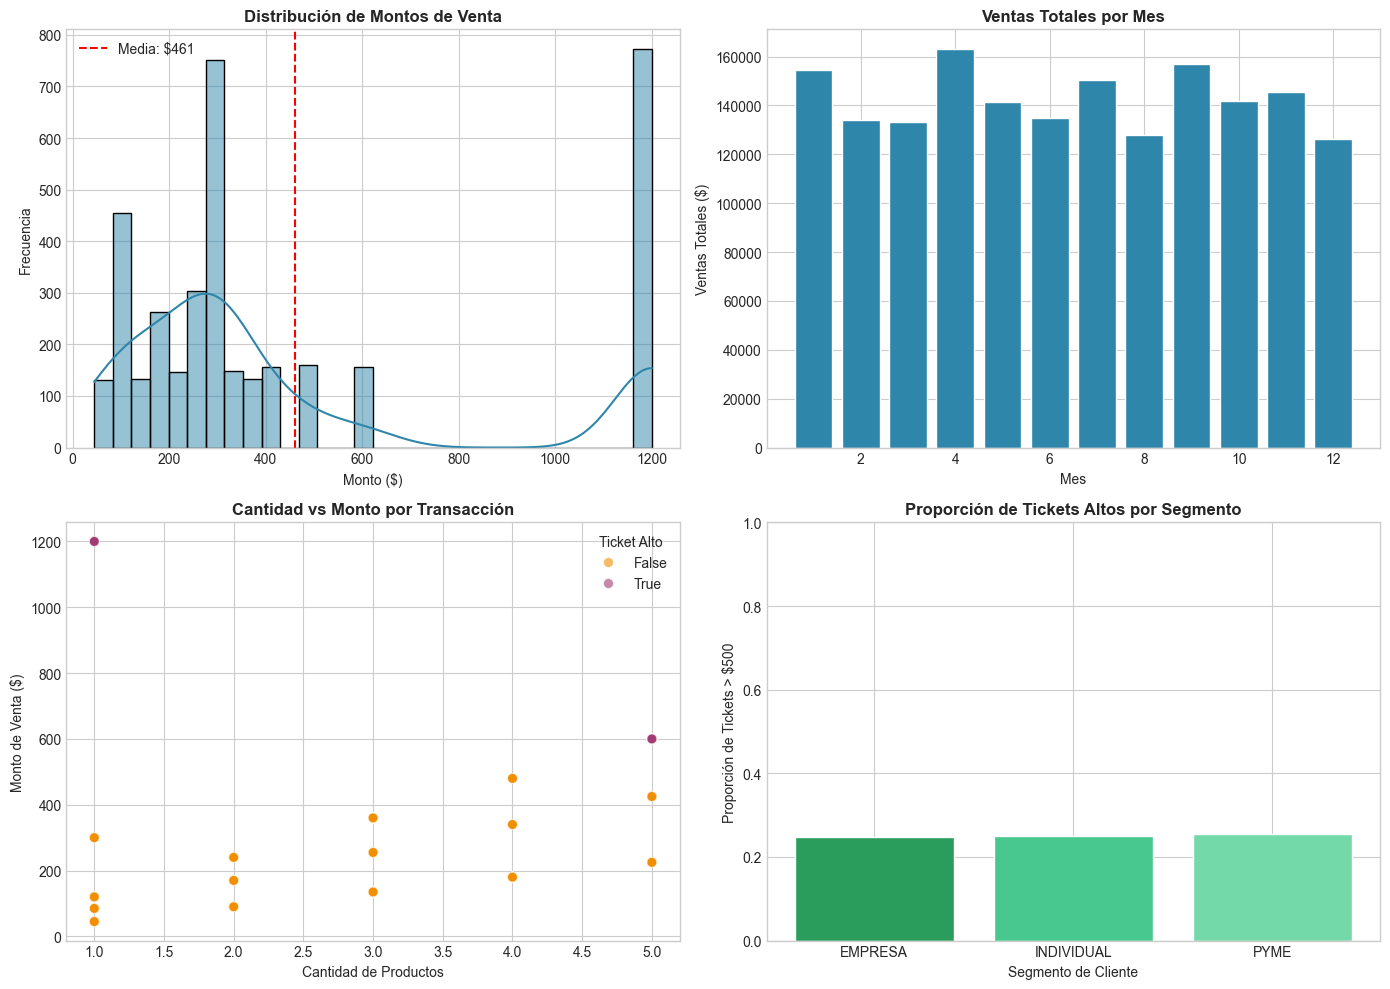


 Visualizaciones generadas y guardadas como 'eda_visualizacion.png'

Hallazgos clave del análisis gráfico:
 • Distribución de montos: Asimetría positiva (media $461 vs mediana $300)
   → Media > Mediana indica presencia de tickets extremos
 • Meses con mayor volumen de ventas: [4, 9, 1]
   → Planificar inventario y promociones antes de estos picos
 • Relación no lineal: Aumentar cantidad no siempre aumenta monto proporcionalmente
 • PYME tiene la mayor proporción de tickets altos (25.6%)
   vs EMPRESA con la menor (24.8%)

 ANÁLISIS FORMAL: Cuantificando patrones con rigor estadístico

1. ESTADÍSTICAS DESCRIPTIVAS CLAVE:
 • Monto promedio: $461.01
 • Mediana: $300.00 (menor que la media → asimetría positiva)
 • Desviación estándar: $398.26 (alta variabilidad)
 • Rango intercuartílico (IQR): $420.00

2. CORRELACIONES ESTADÍSTICAS:
 • Correlación cantidad-monto: -0.248 (moderada, no perfecta)
 → Confirmación: Aumentar cantidad no garantiza aumento proporcional en monto

3. PRUEBA DE HIP

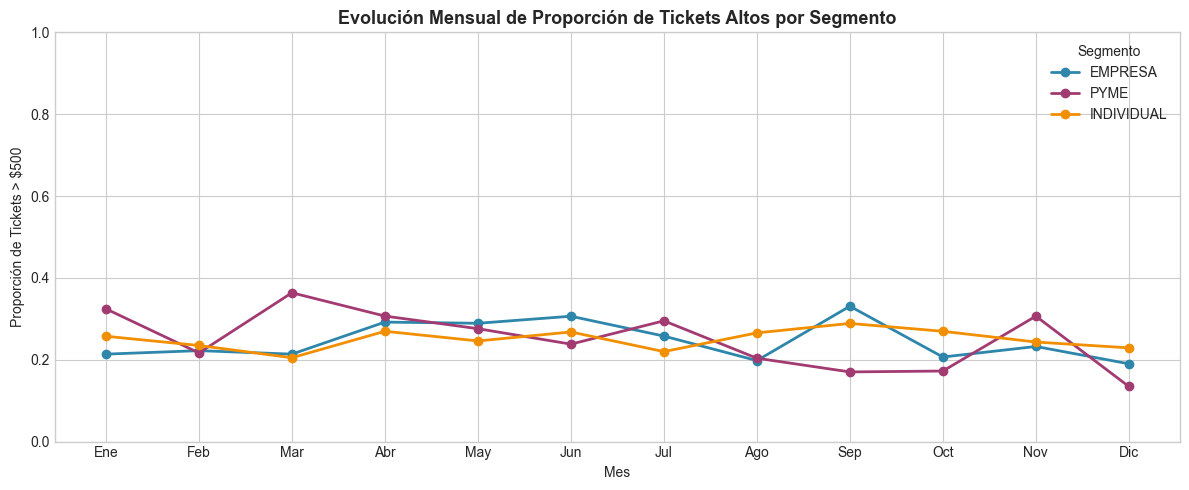

 Gráfica guardada como 'eda_temporal_tickets.png'

 REFLEXIÓN: ¿Por qué es crítico realizar EDA antes del modelado?

[CASO CONCRETO EN ESTE DATASET]
 Sin EDA, un modelo de regresión habría asumido distribución normal en monto_venta.
 Sin embargo, el EDA reveló asimetría positiva: la media ($461) supera a la mediana ($300).
 Consecuencia: Sin transformación logarítmica, el modelo habría sobreestimado
 el ticket promedio en segmentos de bajo valor, generando recomendaciones erróneas.

[LECCIÓN GENERAL]
 El EDA es el paso que convierte suposiciones en evidencia. Saltarlo implica:
 • Modelar sobre distribuciones incorrectas → coeficientes sesgados.
 • Ignorar outliers influyentes → modelos frágiles ante datos reales.
 • Omitir correlaciones entre variables → modelos con multicolinealidad oculta.
 El EDA no retrasa el proyecto; evita que el modelado entero deba rehacerse.


In [6]:
# Instanciar el EDA mejorado (requiere datos_transformados para el chi-cuadrado)
eda_mejorado = AnalisisExploratorioDatosMejorado(
    etl.almacen_datos,
    etl.datos_transformados
)

# Ejecutar análisis base
eda_mejorado.analisis_grafico()
eda_mejorado.analisis_formal()
eda_mejorado.sintesis_insights()

# Ejecutar las nuevas funcionalidades
eda_mejorado.correlacion_categorica_chi2()
eda_mejorado.outliers_iqr_adaptable(multiplicador=1.5)
eda_mejorado.visualizacion_temporal_tickets_altos()
eda_mejorado.reflexion_eda_previo_modelado()

## Desarrollo con evidencias

A lo largo del notebook se mostró la ejecución del EDA original y del EDA mejorado.
Las salidas generadas permiten comprobar la detección visual de patrones mediante histogramas,
gráficos de barras y scatter plots; la cuantificación estadística mediante estadísticas descriptivas,
correlaciones y pruebas de hipótesis; el análisis de asociación entre variables categóricas
mediante chi-cuadrado; la detección de outliers con umbral adaptable; y la evolución temporal
de tickets altos segmentada por tipo de cliente.

## Conclusiones
El EDA demostró ser una fase indispensable que transforma datos crudos en comprensión accionable.
El enfoque dual —gráfico y formal— permitió no solo identificar patrones visuales intuitivos sino
validarlos estadísticamente, evitando conclusiones basadas en coincidencias visuales sin soporte
cuantitativo. La prueba chi-cuadrado reveló si la elección del canal de venta es independiente
del segmento del cliente, una relación que un modelo predictivo asumiría incorrectamente sin este
análisis previo. La detección de outliers con umbral adaptable demostró que la sensibilidad del
criterio de corte impacta directamente la cantidad de casos marcados para revisión, justificando
la parametrización explícita. La visualización temporal por segmento aportó una dimensión adicional
al análisis estático, revelando si las diferencias entre segmentos son consistentes o estacionales.
En conjunto, el EDA no es un paso previo opcional; es la inversión que protege la validez de todo
el modelado posterior.

## Glosario
**EDA (Exploratory Data Analysis):** Fase del KDD donde se exploran los datos mediante visualizaciones y estadísticas para entender su naturaleza antes de modelar.  
**Análisis gráfico:** Uso de histogramas, scatter plots, gráficos de barras y series temporales para detectar patrones visuales en los datos.  
**Análisis formal:** Uso de estadísticas descriptivas, correlaciones y pruebas de hipótesis para cuantificar y validar observaciones del análisis gráfico.  
**Chi-cuadrado:** Prueba estadística que evalúa si existe asociación entre dos variables categóricas; p < 0.05 indica dependencia significativa.  
**IQR (Rango Intercuartílico):** Diferencia entre el tercer y primer cuartil; base del método más robusto para detectar outliers en distribuciones asimétricas.  
**Outlier:** Valor que se aleja significativamente del comportamiento esperado del conjunto de datos y puede distorsionar el modelado si no se trata adecuadamente.  
**Asimetría positiva:** Distribución donde la cola derecha es más larga que la izquierda; la media supera a la mediana, indicando presencia de valores extremos altos.